# 03 — Comparaison des modèles Machine Learning

## 1. Objectif C1

Objectif : comparer plusieurs familles d’algorithmes sur exactement les mêmes données et avec les mêmes métriques afin de sélectionner le modèle le plus adapté à la détection de spam.

Les modèles comparés sont :

- Logistic Regression
- Linear SVM
- Random Forest

Cette comparaison permet de démontrer la compétence C1.

In [1]:
from io import BytesIO
from pathlib import Path
import os
import sys

candidates = [Path.cwd(), Path.cwd().parent]
PROJECT_ROOT = next(path for path in candidates if (path / 'config' / 'config.yaml').exists())
os.chdir(PROJECT_ROOT)
sys.path.insert(0, str(PROJECT_ROOT / 'src'))

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display, Image
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC

from spamguard.data import (
    deduplicate_french_text,
    load_frozen_split,
    load_processed_data,
)

RANDOM_SEED = 42

## 2. Même train et même test

Le dataset audité est dédupliqué selon la même règle que dans le notebook 02, puis le split train/test figé est rechargé.

**Tous les modèles sont évalués sur exactement les mêmes SMS afin que la comparaison soit équitable.**

In [2]:
data = load_processed_data()
deduplicated = deduplicate_french_text(data)
train, test = load_frozen_split(deduplicated)

shared_texts = set(train['text_fr']).intersection(test['text_fr'])
print(f'Train : {len(train)} SMS')
print(f'Test : {len(test)} SMS')
print(f'Textes identiques entre train et test : {len(shared_texts)}')
assert len(train) == 4107
assert len(test) == 1027
assert len(shared_texts) == 0

Train : 4107 SMS
Test : 1027 SMS
Textes identiques entre train et test : 0


## 3. Même pré-processing TF-IDF

La même vectorisation TF-IDF est utilisée pour les trois modèles afin de comparer uniquement l’effet de l’algorithme.

In [3]:
def make_tfidf_vectorizer():
    return TfidfVectorizer(
        lowercase=True,
        ngram_range=(1, 2),
        min_df=2,
        max_df=0.95,
        sublinear_tf=True,
    )


def metric_row(model_name, y_true, y_pred):
    return {
        'Modèle': model_name,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision spam': precision_score(
            y_true, y_pred, pos_label='spam', zero_division=0
        ),
        'Recall spam': recall_score(
            y_true, y_pred, pos_label='spam', zero_division=0
        ),
        'F1-score spam': f1_score(
            y_true, y_pred, pos_label='spam', zero_division=0
        ),
    }


def display_model_metrics(row):
    table = pd.DataFrame({
        'Métrique': ['Accuracy', 'Precision spam', 'Recall spam', 'F1-score spam'],
        'Valeur': [
            row['Accuracy'],
            row['Precision spam'],
            row['Recall spam'],
            row['F1-score spam'],
        ],
    })
    display(table.style.format({'Valeur': '{:.2%}'}))


results = []

## 4. Modèle 1 — Logistic Regression

Logistic Regression est un modèle linéaire simple et interprétable. Il constitue notre baseline.

In [4]:
logistic_pipeline = Pipeline([
    ('tfidf', make_tfidf_vectorizer()),
    ('classifier', LogisticRegression(
        class_weight='balanced',
        max_iter=1000,
        solver='liblinear',
        random_state=RANDOM_SEED,
    )),
])

logistic_pipeline.fit(train['text_fr'], train['label'])
logistic_predictions = logistic_pipeline.predict(test['text_fr'])
logistic_metrics = metric_row(
    'Logistic Regression', test['label'], logistic_predictions
)
results.append(logistic_metrics)
display_model_metrics(logistic_metrics)

,Métrique,Valeur
0,Accuracy,98.15%
1,Precision spam,90.98%
2,Recall spam,94.53%
3,F1-score spam,92.72%


## 5. Modèle 2 — Linear SVM

Linear SVM est également un modèle linéaire. Il cherche une frontière de séparation avec une marge maximale entre les classes. Il est particulièrement adapté aux données textuelles de grande dimension.

In [5]:
svm_pipeline = Pipeline([
    ('tfidf', make_tfidf_vectorizer()),
    ('classifier', LinearSVC(
        class_weight='balanced',
        random_state=RANDOM_SEED,
    )),
])

svm_pipeline.fit(train['text_fr'], train['label'])
svm_predictions = svm_pipeline.predict(test['text_fr'])
svm_metrics = metric_row('Linear SVM', test['label'], svm_predictions)
results.append(svm_metrics)
display_model_metrics(svm_metrics)

,Métrique,Valeur
0,Accuracy,98.64%
1,Precision spam,95.24%
2,Recall spam,93.75%
3,F1-score spam,94.49%


## 6. Modèle 3 — Random Forest

Random Forest combine plusieurs arbres de décision. Il représente une famille différente des modèles linéaires et permet donc une comparaison intéressante pour C1.

Il est cependant moins naturellement adapté aux données TF-IDF très nombreuses et creuses.

In [6]:
forest_pipeline = Pipeline([
    ('tfidf', make_tfidf_vectorizer()),
    ('classifier', RandomForestClassifier(
        n_estimators=300,
        class_weight='balanced',
        random_state=RANDOM_SEED,
        n_jobs=-1,
    )),
])

forest_pipeline.fit(train['text_fr'], train['label'])
forest_predictions = forest_pipeline.predict(test['text_fr'])
forest_metrics = metric_row('Random Forest', test['label'], forest_predictions)
results.append(forest_metrics)
display_model_metrics(forest_metrics)

,Métrique,Valeur
0,Accuracy,97.76%
1,Precision spam,92.00%
2,Recall spam,89.84%
3,F1-score spam,90.91%


## 7. Tableau comparatif principal

Les quatre métriques principales sont calculées sur le même jeu de test.

In [7]:
comparison = pd.DataFrame(results)
metric_columns = ['Accuracy', 'Precision spam', 'Recall spam', 'F1-score spam']
display(
    comparison[['Modèle', *metric_columns]]
      .style.format({column: '{:.2%}' for column in metric_columns})
)

,Modèle,Accuracy,Precision spam,Recall spam,F1-score spam
0,Logistic Regression,98.15%,90.98%,94.53%,92.72%
1,Linear SVM,98.64%,95.24%,93.75%,94.49%
2,Random Forest,97.76%,92.00%,89.84%,90.91%


### Interprétation

- **Linear SVM** obtient la meilleure Accuracy.
- **Linear SVM** obtient la meilleure Precision spam.
- **Logistic Regression** obtient légèrement le meilleur Recall spam.
- **Linear SVM** obtient le meilleur F1-score spam.

Le choix du meilleur modèle ne repose donc pas uniquement sur une métrique, mais sur le compromis global entre les performances et les caractéristiques de l’algorithme.

## 8. Caractéristiques des algorithmes

| Modèle | Famille | Avantage principal | Limite |
|---|---|---|---|
| Logistic Regression | Linéaire | Simple et interprétable | Légèrement moins précise |
| Linear SVM | Linéaire à marge maximale | Très efficace sur le texte TF-IDF | Moins directement probabiliste |
| Random Forest | Ensemble d’arbres | Modèle non linéaire et robuste | Moins adapté aux données TF-IDF très dimensionnelles |

Cette lecture complète la comparaison des performances par les caractéristiques propres à chaque famille d’algorithmes.

## 9. Modèle retenu : Linear SVM

Linear SVM est retenu comme modèle final car il obtient les meilleures performances globales : meilleure Accuracy, meilleure Precision spam et meilleur F1-score spam.

La Logistic Regression obtient un Recall légèrement supérieur, mais Linear SVM présente le meilleur compromis global.

Il est également bien adapté aux données textuelles vectorisées par TF-IDF.

## 10. Matrice de confusion du modèle retenu

La matrice affiche les classes réelles en ligne et les classes prédites en colonne.

,nombre
Vrais négatifs (TN),893
Faux positifs (FP),6
Faux négatifs (FN),8
Vrais positifs (TP),120


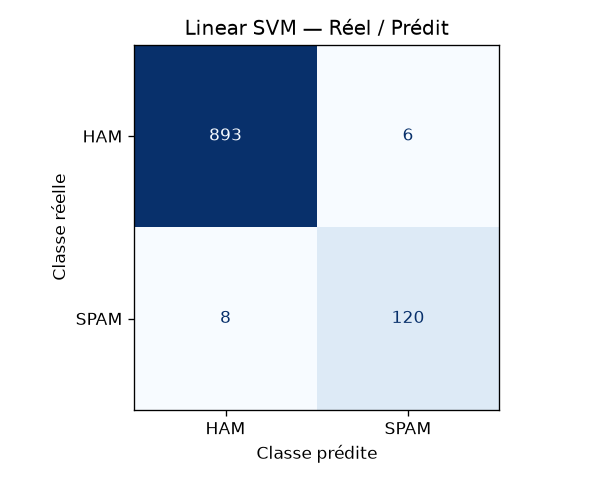

Le modèle laisse passer 8 spams et classe à tort 6 SMS légitimes comme spam.


In [8]:
svm_matrix = confusion_matrix(
    test['label'], svm_predictions, labels=['ham', 'spam']
)
tn, fp, fn, tp = svm_matrix.ravel()

display(pd.Series({
    'Vrais négatifs (TN)': int(tn),
    'Faux positifs (FP)': int(fp),
    'Faux négatifs (FN)': int(fn),
    'Vrais positifs (TP)': int(tp),
}).to_frame('nombre'))

figure, axis = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(
    confusion_matrix=svm_matrix,
    display_labels=['HAM', 'SPAM'],
).plot(cmap='Blues', colorbar=False, ax=axis)
axis.set_title('Linear SVM — Réel / Prédit')
axis.set_xlabel('Classe prédite')
axis.set_ylabel('Classe réelle')
figure.tight_layout()

image_buffer = BytesIO()
figure.savefig(image_buffer, format='png', dpi=120)
plt.close(figure)
display(Image(data=image_buffer.getvalue()))

print(
    f'Le modèle laisse passer {fn} spams et classe à tort '
    f'{fp} SMS légitimes comme spam.'
)

## 11. Conclusion C1

Trois familles de modèles ont été comparées sur les mêmes données et avec les mêmes métriques. Linear SVM présente le meilleur compromis global et est retenu comme modèle final. Cette comparaison permet de justifier le choix de l’algorithme conformément à la compétence C1.